# Hyperliquid L4 Post-Trade Analysis

This notebook uses Polaris raw Hyperliquid events to build participant-attributed post-trade analytics.
The venue-native trade payload supplies the buyer and seller wallets, the aggressing side, transaction
hash, and trade ID that are intentionally absent from the normalized trade projection.

Here, **L4** means wallet-attributed executed trades: participant flow, maker/taker roles,
counterparties, execution cost, and forward midpoint markouts. It does not mean a complete order
lifecycle reconstruction, because the public trade event does not contain every order-state transition.


## Setup and configuration

Run `make install` once from the repository root, then start JupyterLab with `make notebook`.
The example discovers a recent active interval from the open catalog and does not require an API key.

The analysis uses 5 seconds of pre-trade reference data and 65 seconds after the analysis window so
every trade can be evaluated at the 5s, 30s, and 60s horizons. If the catalog edge is sparse, the
notebook searches backward for up to 24 hours.


In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from polaris_data import PolarisClient

for _candidate in (Path.cwd() / "notebooks", Path.cwd()):
    if (_candidate / "_polaris.py").exists():
        sys.path.insert(0, str(_candidate))
        break

from _polaris import accessible_bounds, bounded_rows

plt.style.use("seaborn-v0_8-darkgrid")
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 100)
warnings.filterwarnings("ignore", message=r".*snapshot coverage.*", category=UserWarning)



def fetch_events(source, market, start, end, row_cap):
    with PolarisClient() as client:
        iterator = client.events(
            source=source,
            market=market,
            from_=start,
            to=end,
            allow_gaps=True,
            materialize_orderbooks=False,
        )
        events, truncated = bounded_rows(iterator, row_cap)
    if truncated:
        raise RuntimeError(
            f"The event query exceeded the {row_cap:,}-row notebook cap. "
            "Shorten window_length before continuing so the analysis is not partial."
        )
    return events


def raw_channel(event):
    return (event.get("raw") or {}).get("channel")


def short_wallet(value):
    if not isinstance(value, str) or len(value) < 13:
        return value
    return f"{value[:6]}…{value[-4:]}"


In [2]:
source = "hyperliquid"
market = "BTC"
window_length = pd.Timedelta(minutes=15)
lookback = pd.Timedelta(seconds=5)
markout_horizons = (5, 30, 60)
reference_tolerance = pd.Timedelta(seconds=5)
forward_buffer = pd.Timedelta(seconds=max(markout_horizons)) + reference_tolerance
row_cap = 100_000
search_steps = 24 * 60 // int(window_length / pd.Timedelta(minutes=1))


## Find a recent active public window

Catalog coverage can extend slightly beyond the most recent locally available event snapshot. A probe
therefore searches backward in 15-minute chunks. Once it finds raw trades and normalized midpoints, the
latest observed exchange timestamp anchors a fresh 15-minute analysis window with complete forward
reference coverage.


In [3]:
with PolarisClient() as client:
    catalog = client.catalog(source=source, market=market)

market_info = catalog["markets"][0]
available_start, available_end = accessible_bounds(market_info)

probe_events = None
for offset in range(search_steps):
    probe_end = available_end - offset * window_length
    probe_start = max(available_start, probe_end - window_length)
    if probe_start >= probe_end:
        break
    candidate = fetch_events(source, market, probe_start, probe_end, row_cap)
    has_trades = any(raw_channel(event) == "trades" for event in candidate)
    has_midpoint = any(
        event.get("type") == "point" and (event.get("data") or {}).get("series") == "mid_px"
        for event in candidate
    )
    if has_trades and has_midpoint:
        probe_events = candidate
        break

if not probe_events:
    raise RuntimeError(f"No trades with midpoint context found for {source}:{market} in the last 24 hours")

latest_event_time = pd.to_datetime(
    max(event["exchange_timestamp"] for event in probe_events if event.get("exchange_timestamp") is not None),
    unit="ms",
    utc=True,
)
window_end = latest_event_time - forward_buffer
window_start = window_end - window_length
fetch_start = max(available_start, window_start - lookback)
fetch_end = min(available_end, window_end + forward_buffer)

events = fetch_events(source, market, fetch_start, fetch_end, row_cap)

print(f"Catalog coverage: {available_start} -> {available_end}")
print(f"Analysis window: {window_start} -> {window_end}")
print(f"Fetched with reference buffers: {fetch_start} -> {fetch_end}")
print(f"Event rows: {len(events):,}")
pd.Series(market_info)


Catalog coverage: 2026-07-25 00:40:41.736000+00:00 -> 2026-09-03 00:01:12.205000+00:00
Analysis window: 2026-09-02 23:43:54.531000+00:00 -> 2026-09-02 23:58:54.531000+00:00
Fetched with reference buffers: 2026-09-02 23:43:49.531000+00:00 -> 2026-09-02 23:59:59.531000+00:00
Event rows: 7,008


access                                                          {'public_cutoff_date': None, 'status': 'open'}
categories                                                                                              [perp]
end                                                                                   2026-09-03T00:01:12.205Z
instrument     {'base': 'BTC', 'lot_size': '0.00001', 'min_notional': '10', 'quote': 'USD', 'tick_size': None}
market                                                                                                     BTC
source                                                                                             hyperliquid
source_type                                                                                               None
start                                                                                 2026-07-25T00:40:41.736Z
symbol                                                                                                  BTCUSD
d

## Inspect the event envelope and venue-native trade

Polaris keeps a normalized `data` projection beside the original venue message in `raw`. Hyperliquid's
[`WsTrade`](https://hyperliquid.gitbook.io/hyperliquid-docs/for-developers/api/websocket/subscriptions)
defines `users` as `[buyer, seller]`, and its trade `side` is the aggressing side. `tid` is only globally
unique when combined with block time and coin, so this notebook uses `(time, coin, tid)` as its identity.


In [4]:
trade_event_sample = next(event for event in events if raw_channel(event) == "trades")
raw_batch = trade_event_sample["raw"]["data"]

event_envelope = pd.Series({
    "source": trade_event_sample.get("source"),
    "market": trade_event_sample.get("market"),
    "type": trade_event_sample.get("type"),
    "exchange_timestamp": pd.to_datetime(trade_event_sample.get("exchange_timestamp"), unit="ms", utc=True),
    "collector_timestamp": pd.to_datetime(trade_event_sample.get("collector_timestamp"), unit="ms", utc=True),
    "normalized_data": trade_event_sample.get("data"),
    "raw_channel": trade_event_sample["raw"].get("channel"),
    "raw_batch_size": len(raw_batch),
})

display(event_envelope.to_frame("value"))
raw_trade_preview = dict(raw_batch[0])
raw_trade_preview["users"] = [short_wallet(wallet) for wallet in raw_trade_preview.get("users", [])]
display(pd.Series(raw_trade_preview, name="first raw trade (wallets shortened)").to_frame())


,value
source,hyperliquid
market,BTC
type,trade
exchange_timestamp,2026-09-02 23:43:52.379000+00:00
collector_timestamp,2026-09-02 23:43:52.596000+00:00
normalized_data,"{'order_id': None, 'price': 77098.0, 'quantity': 0.00014, 'side': 'buy'}"
raw_channel,trades
raw_batch_size,1


,first raw trade (wallets shortened)
coin,BTC
hash,0xd793737d2f9cd2cbd90d04438e4ba40201050062ca9ff19d7b5c1ecfee90acb6
px,77098.0
side,B
sz,0.00014
tid,302953240644815
time,1788392632379
users,"[0x9d1c…301a, 0xa2e5…a6c8]"


## Flatten and deduplicate raw trades

One Hyperliquid WebSocket message can contain a batch of trades. Polaris emits one normalized event per
trade while retaining the complete original batch on each projection, so flattening every `raw.data`
array repeats records. The composite trade identity removes those repetitions without relying on
transaction hash: a zero hash is valid for some TWAP fills.


In [5]:
raw_trade_rows = [
    trade
    for event in events
    if raw_channel(event) == "trades"
    for trade in ((event.get("raw") or {}).get("data") or [])
]

raw_trades = pd.DataFrame(raw_trade_rows)
required_raw_columns = ["time", "coin", "tid", "px", "sz", "side", "hash", "users"]
missing_columns = sorted(set(required_raw_columns) - set(raw_trades.columns))
if missing_columns:
    raise ValueError(f"Raw Hyperliquid trade payload is missing columns: {missing_columns}")

identity_columns = ["time", "coin", "tid"]
unique_trades = raw_trades.drop_duplicates(identity_columns).copy()
unique_trades["participant_pair_valid"] = unique_trades["users"].map(
    lambda value: isinstance(value, (list, tuple)) and len(value) == 2
)
unique_trades["side_valid"] = unique_trades["side"].isin(["A", "B"])

integrity = pd.Series({
    "event_rows": len(events),
    "normalized_trade_events": sum(event.get("type") == "trade" for event in events),
    "flattened_raw_observations": len(raw_trades),
    "unique_raw_trades": len(unique_trades),
    "repeated_raw_observations_removed": len(raw_trades) - len(unique_trades),
    "invalid_participant_pairs": int((~unique_trades["participant_pair_valid"]).sum()),
    "unsupported_sides": int((~unique_trades["side_valid"]).sum()),
    "duplicate_identities_after_dedup": int(unique_trades.duplicated(identity_columns).sum()),
    "zero_hash_trades": int((unique_trades["hash"] == "0x" + "0" * 64).sum()),
})
display(integrity.to_frame("count"))

valid_trades = unique_trades.loc[
    unique_trades["participant_pair_valid"] & unique_trades["side_valid"]
].copy()
if valid_trades.empty:
    raise RuntimeError("No valid participant-attributed trades remain after raw-payload validation")

valid_trades["timestamp"] = pd.to_datetime(valid_trades["time"], unit="ms", utc=True)
valid_trades["price"] = pd.to_numeric(valid_trades["px"], errors="raise")
valid_trades["quantity"] = pd.to_numeric(valid_trades["sz"], errors="raise")
valid_trades["notional_usd"] = valid_trades["price"] * valid_trades["quantity"]
valid_trades["buyer"] = valid_trades["users"].str[0]
valid_trades["seller"] = valid_trades["users"].str[1]
valid_trades["aggressor_side"] = valid_trades["side"].map({"B": "buy", "A": "sell"})
valid_trades["aggressor_sign"] = valid_trades["side"].map({"B": 1.0, "A": -1.0})
valid_trades["aggressor_wallet"] = valid_trades["buyer"].where(
    valid_trades["side"] == "B", valid_trades["seller"]
)
valid_trades["passive_wallet"] = valid_trades["seller"].where(
    valid_trades["side"] == "B", valid_trades["buyer"]
)
valid_trades["trade_id"] = (
    valid_trades["time"].astype(str) + ":" + valid_trades["coin"] + ":" + valid_trades["tid"].astype(str)
)

trades_df = (
    valid_trades.loc[
        valid_trades["timestamp"].between(window_start, window_end, inclusive="left"),
        [
            "trade_id", "timestamp", "coin", "tid", "hash", "price", "quantity", "notional_usd",
            "buyer", "seller", "aggressor_side", "aggressor_sign", "aggressor_wallet", "passive_wallet",
        ],
    ]
    .sort_values("timestamp")
    .reset_index(drop=True)
)

assert trades_df["trade_id"].is_unique
assert trades_df[["buyer", "seller"]].notna().all().all()
assert (trades_df["quantity"] > 0).all()

print(f"Analysis trades: {len(trades_df):,}")
trade_preview = trades_df.head().copy()
for wallet_column in ["buyer", "seller", "aggressor_wallet", "passive_wallet"]:
    trade_preview[wallet_column] = trade_preview[wallet_column].map(short_wallet)
trade_preview


,count
event_rows,7008
normalized_trade_events,1851
flattened_raw_observations,16173
unique_raw_trades,1851
repeated_raw_observations_removed,14322
invalid_participant_pairs,0
unsupported_sides,0
duplicate_identities_after_dedup,0
zero_hash_trades,304


Analysis trades: 1,585


,trade_id,timestamp,coin,tid,hash,price,quantity,notional_usd,buyer,seller,aggressor_side,aggressor_sign,aggressor_wallet,passive_wallet
0,1788392635001:BTC:306034017868217,2026-09-02 23:43:55.001000+00:00,BTC,306034017868217,0x0000000000000000000000000000000000000000000000000000000000000000,77098.0,0.00514,396.28372,0x99b9…9578,0xa2e5…a6c8,buy,1.0,0x99b9…9578,0xa2e5…a6c8
1,1788392635001:BTC:381286539048491,2026-09-02 23:43:55.001000+00:00,BTC,381286539048491,0x0000000000000000000000000000000000000000000000000000000000000000,77098.0,0.00208,160.36384,0x99b9…9578,0x6ab9…8b9d,buy,1.0,0x99b9…9578,0x6ab9…8b9d
2,1788392635001:BTC:847387464888935,2026-09-02 23:43:55.001000+00:00,BTC,847387464888935,0x0000000000000000000000000000000000000000000000000000000000000000,77098.0,0.01849,1425.54202,0x99b9…9578,0xf5d8…ad53,buy,1.0,0x99b9…9578,0xf5d8…ad53
3,1788392635001:BTC:1117509111002285,2026-09-02 23:43:55.001000+00:00,BTC,1117509111002285,0x0000000000000000000000000000000000000000000000000000000000000000,77098.0,0.00030,23.12940,0xc35b…d8dd,0xf5d8…ad53,buy,1.0,0xc35b…d8dd,0xf5d8…ad53
4,1788392636048:BTC:166866825252934,2026-09-02 23:43:56.048000+00:00,BTC,166866825252934,0x0000000000000000000000000000000000000000000000000000000000000000,77097.0,0.00096,74.01312,0x932f…1873,0x6e28…f5f5,sell,-1.0,0x6e28…f5f5,0x932f…1873


## Attach arrival and forward midpoints

The normalized `point` event carries Hyperliquid's midpoint as `series == "mid_px"`. Repeated point
projections are deduplicated by exchange timestamp and midpoint. Arrival joins look backward; markout
joins look forward from each exact horizon target. Unmatched rows remain missing and are reported
explicitly.


In [6]:
midpoint_rows = []
for event in events:
    if event.get("type") != "point":
        continue
    data = event.get("data") or {}
    if data.get("series") != "mid_px" or data.get("value") is None or event.get("exchange_timestamp") is None:
        continue
    midpoint_rows.append({
        "mid_timestamp": pd.to_datetime(event["exchange_timestamp"], unit="ms", utc=True),
        "mid_price": float(data["value"]),
    })

midpoints_df = (
    pd.DataFrame(midpoint_rows)
    .drop_duplicates(["mid_timestamp", "mid_price"])
    .sort_values("mid_timestamp")
    .reset_index(drop=True)
)
if midpoints_df.empty:
    raise RuntimeError("No normalized mid_px point observations were available")

analysis_df = pd.merge_asof(
    trades_df.sort_values("timestamp"),
    midpoints_df,
    left_on="timestamp",
    right_on="mid_timestamp",
    direction="backward",
    tolerance=lookback,
).rename(columns={"mid_timestamp": "arrival_mid_timestamp", "mid_price": "arrival_mid"})

analysis_df["arrival_cost_bps"] = (
    analysis_df["aggressor_sign"]
    * (analysis_df["price"] - analysis_df["arrival_mid"])
    / analysis_df["arrival_mid"]
    * 10_000
)

coverage_rows = [{
    "reference": "arrival",
    "matched": int(analysis_df["arrival_mid"].notna().sum()),
    "unmatched": int(analysis_df["arrival_mid"].isna().sum()),
}]

for horizon in markout_horizons:
    target_column = f"target_{horizon}s"
    reference_time_column = f"mid_timestamp_{horizon}s"
    reference_price_column = f"mid_{horizon}s"
    markout_column = f"markout_{horizon}s_bps"

    targets = analysis_df[["trade_id", "timestamp"]].copy()
    targets[target_column] = (
        targets["timestamp"] + pd.Timedelta(seconds=horizon)
    ).astype("datetime64[ns, UTC]")
    targets = targets.sort_values(target_column)
    horizon_midpoints = midpoints_df.rename(columns={
        "mid_timestamp": reference_time_column,
        "mid_price": reference_price_column,
    })
    horizon_midpoints[reference_time_column] = horizon_midpoints[reference_time_column].astype(
        "datetime64[ns, UTC]"
    )
    joined = pd.merge_asof(
        targets,
        horizon_midpoints,
        left_on=target_column,
        right_on=reference_time_column,
        direction="forward",
        tolerance=reference_tolerance,
    )
    matched = joined[reference_time_column].notna()
    assert (joined.loc[matched, reference_time_column] >= joined.loc[matched, target_column]).all()

    analysis_df = analysis_df.merge(
        joined[["trade_id", target_column, reference_time_column, reference_price_column]],
        on="trade_id",
        how="left",
        validate="one_to_one",
    )
    analysis_df[markout_column] = (
        analysis_df["aggressor_sign"]
        * (analysis_df[reference_price_column] - analysis_df["price"])
        / analysis_df["price"]
        * 10_000
    )
    coverage_rows.append({
        "reference": f"{horizon}s markout",
        "matched": int(analysis_df[reference_price_column].notna().sum()),
        "unmatched": int(analysis_df[reference_price_column].isna().sum()),
    })

reference_coverage = pd.DataFrame(coverage_rows)
reference_coverage["coverage_pct"] = (
    reference_coverage["matched"] / (reference_coverage["matched"] + reference_coverage["unmatched"]) * 100
)
reference_coverage


,reference,matched,unmatched,coverage_pct
0,arrival,1551,34,97.854890
1,5s markout,1556,29,98.170347
2,30s markout,1518,67,95.772871
3,60s markout,1477,108,93.186120


## Market-level post-trade summary

Positive arrival cost means the aggressor traded through the contemporaneous midpoint. Positive
markout means the midpoint subsequently moved in the aggressor's direction. Results are weighted by
trade notional so a burst of tiny prints does not dominate the aggregate view.


In [7]:
all_wallets = pd.concat([analysis_df["buyer"], analysis_df["seller"]], ignore_index=True)
buy_notional = analysis_df.loc[analysis_df["aggressor_side"] == "buy", "notional_usd"].sum()
sell_notional = analysis_df.loc[analysis_df["aggressor_side"] == "sell", "notional_usd"].sum()
total_notional = analysis_df["notional_usd"].sum()

activity_summary = pd.Series({
    "trades": len(analysis_df),
    "base_volume_btc": analysis_df["quantity"].sum(),
    "notional_usd": total_notional,
    "unique_wallets": all_wallets.nunique(),
    "aggressive_buy_notional_pct": 100 * buy_notional / total_notional if total_notional else float("nan"),
    "aggressive_sell_notional_pct": 100 * sell_notional / total_notional if total_notional else float("nan"),
    "net_aggressive_base_btc": (analysis_df["aggressor_sign"] * analysis_df["quantity"]).sum(),
})

markout_rows = []
for label, column in [("arrival cost", "arrival_cost_bps")] + [
    (f"{horizon}s markout", f"markout_{horizon}s_bps") for horizon in markout_horizons
]:
    valid = analysis_df[column].notna()
    weights = analysis_df.loc[valid, "notional_usd"]
    weighted_value = (
        (analysis_df.loc[valid, column] * weights).sum() / weights.sum()
        if weights.sum() else float("nan")
    )
    markout_rows.append({
        "metric": label,
        "notional_weighted_bps": weighted_value,
        "median_bps": analysis_df.loc[valid, column].median(),
        "trades": int(valid.sum()),
    })
markout_summary = pd.DataFrame(markout_rows)

display(activity_summary.to_frame("value"))
display(markout_summary)


,value
trades,1.585000e+03
base_volume_btc,1.283255e+02
notional_usd,9.917368e+06
unique_wallets,4.140000e+02
aggressive_buy_notional_pct,6.431450e+01
aggressive_sell_notional_pct,3.568550e+01
net_aggressive_base_btc,3.673833e+01


,metric,notional_weighted_bps,median_bps,trades
0,arrival cost,0.309460,0.064745,1551
1,5s markout,0.571175,-0.064677,1556
2,30s markout,0.855044,0.194024,1518
3,60s markout,1.669050,0.712906,1477


## Wallet roles, flow, and counterparties

Each trade becomes two participant observations: the buyer receives positive signed flow and the seller
negative signed flow. The aggressing side determines whether each wallet supplied or demanded liquidity.
Full wallet addresses remain in the underlying DataFrames; rendered summaries use shortened labels.


In [8]:
base_columns = [
    "trade_id", "timestamp", "quantity", "notional_usd", "arrival_mid", "price",
] + [f"mid_{horizon}s" for horizon in markout_horizons]

buyers = analysis_df[base_columns].copy()
buyers["wallet"] = analysis_df["buyer"]
buyers["participant_side"] = "buy"
buyers["participant_sign"] = 1.0
buyers["role"] = analysis_df["aggressor_side"].map({"buy": "aggressor", "sell": "passive"})

sellers = analysis_df[base_columns].copy()
sellers["wallet"] = analysis_df["seller"]
sellers["participant_side"] = "sell"
sellers["participant_sign"] = -1.0
sellers["role"] = analysis_df["aggressor_side"].map({"buy": "passive", "sell": "aggressor"})

participants_df = pd.concat([buyers, sellers], ignore_index=True)
participants_df["signed_base"] = participants_df["participant_sign"] * participants_df["quantity"]
participants_df["signed_notional"] = participants_df["participant_sign"] * participants_df["notional_usd"]
participants_df["aggressor_notional"] = participants_df["notional_usd"].where(
    participants_df["role"] == "aggressor", 0.0
)
participants_df["passive_notional"] = participants_df["notional_usd"].where(
    participants_df["role"] == "passive", 0.0
)
participants_df["participant_cost_bps"] = (
    participants_df["participant_sign"]
    * (participants_df["price"] - participants_df["arrival_mid"])
    / participants_df["arrival_mid"]
    * 10_000
)

participant_rows_per_trade = participants_df.groupby("trade_id").size()
assert (participant_rows_per_trade == 2).all()
notional_reconciliation_error = abs(
    participants_df["notional_usd"].sum() - 2 * analysis_df["notional_usd"].sum()
)
assert notional_reconciliation_error < max(1e-6, analysis_df["notional_usd"].sum() * 1e-12)
assert abs(participants_df["signed_base"].sum()) < 1e-9

for horizon in markout_horizons:
    column = f"participant_markout_{horizon}s_bps"
    participants_df[column] = (
        participants_df["participant_sign"]
        * (participants_df[f"mid_{horizon}s"] - participants_df["price"])
        / participants_df["price"]
        * 10_000
    )
    participants_df[f"weighted_markout_{horizon}s"] = participants_df[column] * participants_df["notional_usd"]
    participants_df[f"markout_weight_{horizon}s"] = participants_df["notional_usd"].where(
        participants_df[column].notna(), 0.0
    )

wallet_group = participants_df.groupby("wallet", sort=False)
participant_summary = wallet_group.agg(
    trade_count=("trade_id", "nunique"),
    total_notional=("notional_usd", "sum"),
    aggressor_notional=("aggressor_notional", "sum"),
    passive_notional=("passive_notional", "sum"),
    net_base=("signed_base", "sum"),
    net_notional=("signed_notional", "sum"),
).reset_index()
participant_summary["aggressor_share_pct"] = (
    participant_summary["aggressor_notional"] / participant_summary["total_notional"] * 100
)

for horizon in markout_horizons:
    numerator = wallet_group[f"weighted_markout_{horizon}s"].sum()
    denominator = wallet_group[f"markout_weight_{horizon}s"].sum()
    participant_summary = participant_summary.merge(
        (numerator / denominator.where(denominator != 0))
        .rename(f"weighted_markout_{horizon}s_bps")
        .reset_index(),
        on="wallet",
        how="left",
        validate="one_to_one",
    )

participant_summary["wallet_label"] = participant_summary["wallet"].map(short_wallet)
participant_summary = participant_summary.sort_values("total_notional", ascending=False).reset_index(drop=True)

counterparties = (
    analysis_df.groupby(["buyer", "seller"], as_index=False)
    .agg(trade_count=("trade_id", "nunique"), notional_usd=("notional_usd", "sum"))
    .sort_values("notional_usd", ascending=False)
    .reset_index(drop=True)
)
counterparties["buyer_label"] = counterparties["buyer"].map(short_wallet)
counterparties["seller_label"] = counterparties["seller"].map(short_wallet)

top_wallet_share = (
    participant_summary.head(10)["total_notional"].sum() / participant_summary["total_notional"].sum() * 100
)
print(f"Top 10 wallet share of participant notional: {top_wallet_share:.1f}%")
display(participant_summary[[
    "wallet_label", "trade_count", "total_notional", "aggressor_notional", "passive_notional",
    "net_base", "net_notional", "aggressor_share_pct",
    "weighted_markout_5s_bps", "weighted_markout_30s_bps", "weighted_markout_60s_bps",
]].head(15))
display(counterparties[["buyer_label", "seller_label", "trade_count", "notional_usd"]].head(15))


Top 10 wallet share of participant notional: 57.9%


,wallet_label,trade_count,total_notional,aggressor_notional,passive_notional,net_base,net_notional,aggressor_share_pct,weighted_markout_5s_bps,weighted_markout_30s_bps,weighted_markout_60s_bps
0,0xc179…e0c8,53,1.953651e+06,0.000000e+00,1.953651e+06,2.527007e+01,1.953651e+06,0.000000,-1.908698,-2.392932,-5.367930
1,0x1e9b…3855,90,1.775768e+06,1.775768e+06,0.000000e+00,2.296680e+01,1.775768e+06,100.000000,0.478634,1.307646,4.700025
2,0x10f1…202f,57,1.755393e+06,1.755393e+06,0.000000e+00,2.270651e+01,1.755393e+06,100.000000,0.463258,0.463258,-1.865093
3,0xcf3f…f95f,63,1.557730e+06,8.603207e+05,6.974093e+05,-2.014868e+01,-1.557730e+06,55.229127,1.039705,1.256386,2.934306
4,0xecb6…2b00,64,1.056104e+06,0.000000e+00,1.056104e+06,-1.366935e+01,-1.056104e+06,0.000000,-0.165385,-0.637149,-2.238858
5,0x00f6…0aec,49,7.712439e+05,7.712439e+05,0.000000e+00,-1.942890e-16,2.138642e+02,100.000000,0.144387,-0.439086,-2.124675
6,0x0fd4…e0c7,30,7.636148e+05,5.223292e+05,2.412856e+05,-9.878790e+00,-7.636148e+05,68.402182,0.992832,1.295726,2.609254
7,0x09bc…410d,10,6.614938e+05,1.784778e+05,4.830160e+05,-8.555970e+00,-6.614938e+05,26.981029,0.604828,0.356774,0.380319
8,0x7b7f…dee2,14,5.935938e+05,1.208711e+05,4.727227e+05,-7.680850e+00,-5.935629e+05,20.362595,0.327407,0.127544,0.456208
9,0xf5d8…ad53,94,5.906109e+05,2.640067e+05,3.266042e+05,-1.842100e+00,-1.426142e+05,44.700612,0.478162,0.523763,1.925458


,buyer_label,seller_label,trade_count,notional_usd
0,0xc179…e0c8,0xcf3f…f95f,16,826201.00992
1,0x1e9b…3855,0xecb6…2b00,6,384639.41549
2,0x10f1…202f,0xb705…004a,1,326409.29900
3,0x10f1…202f,0xcf3f…f95f,1,302090.45504
4,0xc179…e0c8,0x0fd4…e0c7,2,288480.58473
5,0x1e9b…3855,0xcf3f…f95f,1,247597.64129
6,0x00f6…0aec,0xecb6…2b00,5,226240.09433
7,0x1e9b…3855,0x09bc…410d,3,210095.04312
8,0x10f1…202f,0x7b7f…dee2,2,193552.70640
9,0xc179…e0c8,0x7ca1…9235,1,179678.49510


## Executions over the midpoint

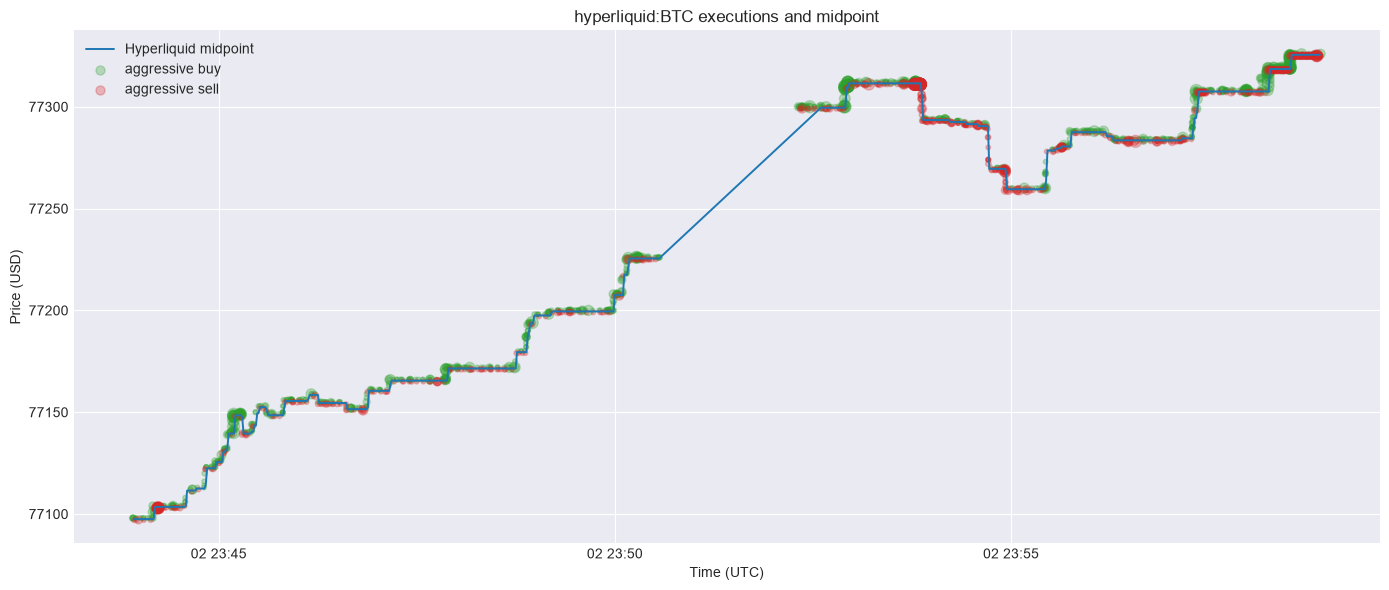

In [9]:
fig, ax = plt.subplots(figsize=(14, 6))
window_midpoints = midpoints_df.loc[
    midpoints_df["mid_timestamp"].between(window_start, window_end, inclusive="both")
]
ax.plot(
    window_midpoints["mid_timestamp"], window_midpoints["mid_price"],
    color="#1f77b4", linewidth=1.4, label="Hyperliquid midpoint",
)

size_cap = analysis_df["notional_usd"].quantile(0.95)
size_cap = size_cap if size_cap > 0 else 1.0
marker_sizes = 10 + 65 * (analysis_df["notional_usd"].clip(upper=size_cap) / size_cap) ** 0.5
for side, color in [("buy", "#2ca02c"), ("sell", "#d62728")]:
    rows = analysis_df["aggressor_side"] == side
    ax.scatter(
        analysis_df.loc[rows, "timestamp"], analysis_df.loc[rows, "price"],
        s=marker_sizes.loc[rows], color=color, alpha=0.28, label=f"aggressive {side}",
    )

ax.set_title(f"{source}:{market} executions and midpoint")
ax.set_xlabel("Time (UTC)")
ax.set_ylabel("Price (USD)")
ax.legend(loc="best")
plt.tight_layout()
plt.show()


## Largest participants by liquidity role

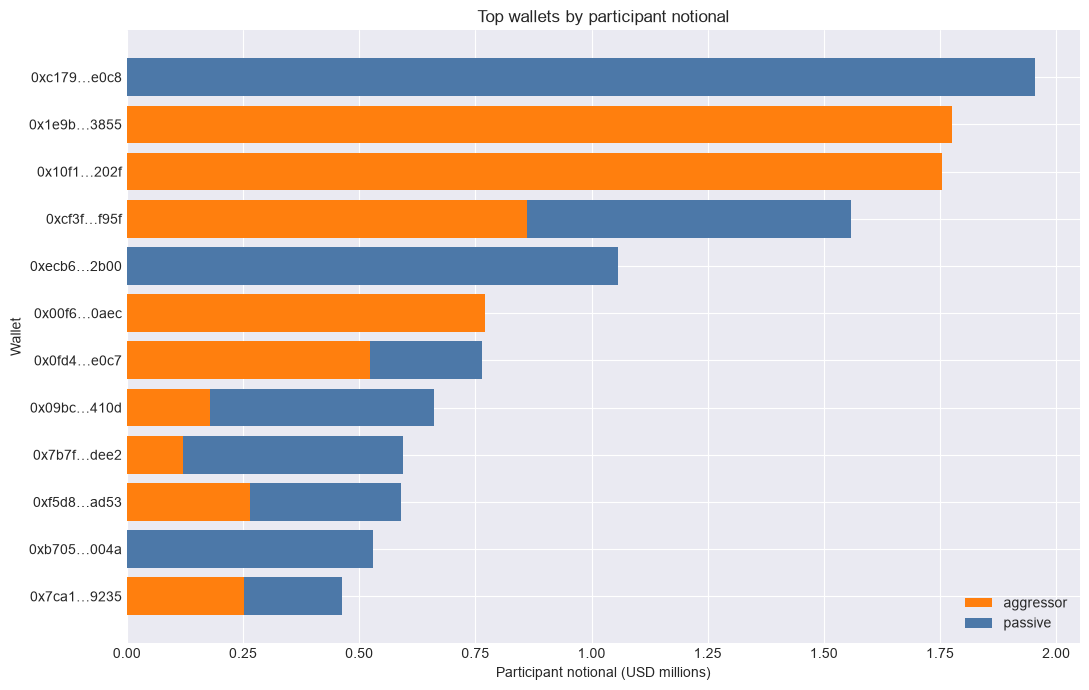

In [10]:
top_participants = participant_summary.head(12).sort_values("total_notional")
fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(
    top_participants["wallet_label"], top_participants["aggressor_notional"] / 1_000_000,
    color="#ff7f0e", label="aggressor",
)
ax.barh(
    top_participants["wallet_label"], top_participants["passive_notional"] / 1_000_000,
    left=top_participants["aggressor_notional"] / 1_000_000,
    color="#4c78a8", label="passive",
)
ax.set_title("Top wallets by participant notional")
ax.set_xlabel("Participant notional (USD millions)")
ax.set_ylabel("Wallet")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


## Aggregate aggressor markout curve

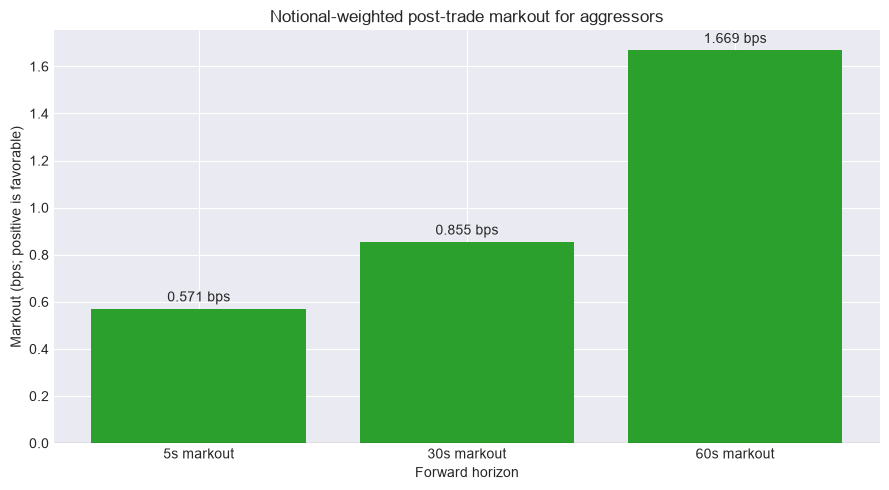

In [11]:
markout_plot = markout_summary.loc[markout_summary["metric"].str.contains("markout")].copy()
fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#2ca02c" if value >= 0 else "#d62728" for value in markout_plot["notional_weighted_bps"]]
bars = ax.bar(markout_plot["metric"], markout_plot["notional_weighted_bps"], color=colors)
ax.axhline(0, color="black", linewidth=0.8)
ax.bar_label(bars, fmt="%.3f bps", padding=3)
ax.set_title("Notional-weighted post-trade markout for aggressors")
ax.set_ylabel("Markout (bps; positive is favorable)")
ax.set_xlabel("Forward horizon")
plt.tight_layout()
plt.show()


## Interpretation and limitations

- Wallet addresses are public account identifiers, not verified trader identities; one entity can control
  many wallets and one wallet can represent a vault or subaccount.
- The raw trade stream supports participant attribution after execution, but it does not expose complete
  order lifecycles, client order IDs, fees, positions, or realized P&L.
- Markouts describe short-horizon price movement around an execution. They are not portfolio returns and
  do not include fees, funding, inventory, hedges, or activity in other markets.
- `0x000…000` transaction hashes can be valid for TWAP fills, so `(time, coin, tid)`—not hash—is used for
  deduplication.
- Results cover a short, dynamically selected public interval and should be treated as a reproducible
  workflow example rather than a persistent ranking of wallets.
